In [ ]:
import os, yaml, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
import networkx as nx
from scipy import stats
from dataclasses import dataclass
import matplotlib as mpl
import matplotlib.ticker as ticker

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for path_key in ["src_path", "useful_stuff_path"]:
    if path_key in paths and paths[path_key] not in sys.path:
        sys.path.append(paths[path_key])
from II_analyses.metrics_comparison import metric_comparison_save_name
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from useful_stuff.general_utils.plots import truncate_colormap

In [118]:
@dataclass
class SuperCfg:
    figs_folder = "/Users/tizianocausin/gdrive/phd/writings/summary_metrics_II/figures"
    labels_fontsize = 30
    ticks_fontsize = 20
    title_fontsize = 40
    save_figs = True
super_cfg = SuperCfg()

loaded 6 sessions from /Users/tizianocausin/metrics_II_local/results
euclidean -> cosine_cnt ; cosine_cnt -> euclidean: t=2.996, p=0.03023, n=6 *
euclidean -> magnitude_diff ; magnitude_diff -> euclidean: t=2.806, p=0.03772, n=6 *
euclidean -> correlation ; correlation -> euclidean: t=3.455, p=0.01814, n=6 *
cosine_cnt -> magnitude_diff ; magnitude_diff -> cosine_cnt: t=1.809, p=0.1303, n=6
cosine_cnt -> correlation ; correlation -> cosine_cnt: t=4.408, p=0.006972, n=6 *
magnitude_diff -> correlation ; correlation -> magnitude_diff: t=-1.038, p=0.3469, n=6


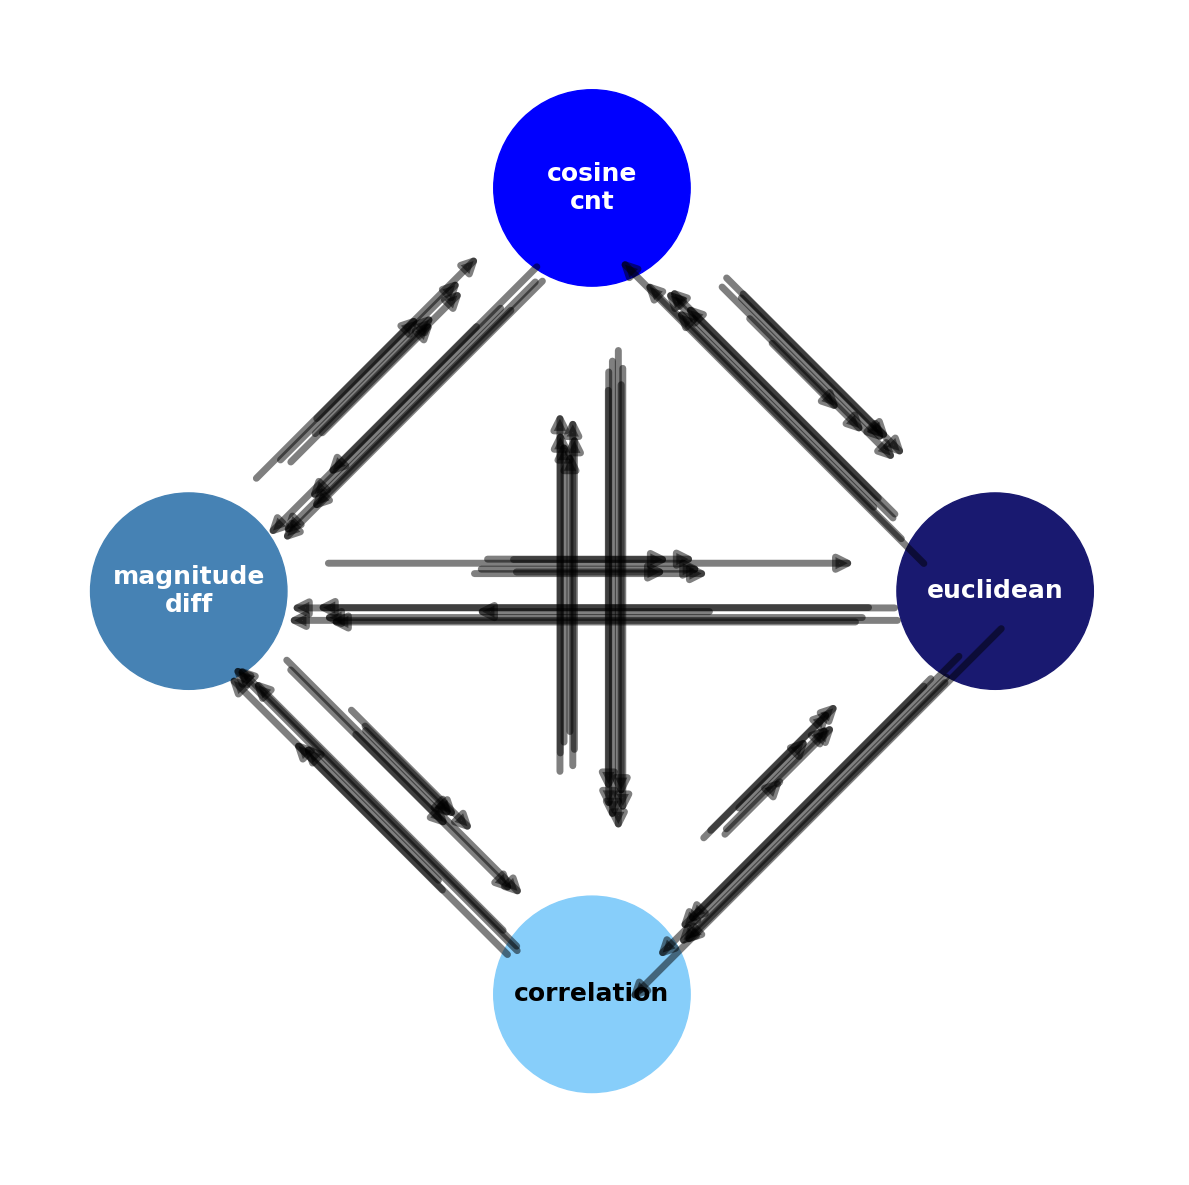

In [ ]:
@dataclass
class Cfg:
    brain_area: str = "AIT"
    new_fs: int = 100
    k: int = 1
    metrics: tuple = ("euclidean", "cosine_cnt", "magnitude_diff", "correlation", )
    sessions: tuple = (
        ("paul", "230204"),
        ("baby1", "220226to527"),
        ("three0", "250313"),
        ("red", "220227"),
        ("octavius", "220227to405"),
        ("baby5", "221104to24")
        # ("baby1", "240816to26"),
    )
    subsamples_size=None
    iterations=None
    results_dir: Path = Path(paths["data_path"]) / "results"
    node_colors: tuple = ("midnightblue", "blue", "steelblue", "lightskyblue")
    jitter: float = 0.01
    jitter_seed: int = 0
    ttest_alpha: float = 0.05
    show_ttest_stars: bool = False
    arrow_visual_power: float = 3.0

cfg = Cfg()
cfg


def metric_comparison_fn(metric_from, metric_to, monkey_name, date, brain_area=None, k=None):
    brain_area = cfg.brain_area if brain_area is None else brain_area
    k = cfg.k if k is None else k
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            monkey_name,
            date,
            brain_area,
            cfg.new_fs,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.iterations
        )
    )

def load_metric_comparison(metric_from, metric_to, monkey_name, date, brain_area=None, k=None):
    fn = metric_comparison_fn(metric_from, metric_to, monkey_name, date, brain_area, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


def metric_informativeness(ii_timecourse, target_metric, comparing_metric):
    if comparing_metric != "magnitude_diff" and target_metric != "magnitude_diff":
        return 1.0 - float(np.nanmax(ii_timecourse))
    return 1.0 - float(np.nanmin(ii_timecourse))


def build_metric_graph(monkey_name, date, brain_area=None, k=None):
    G = nx.DiGraph()
    G.add_nodes_from(cfg.metrics)
    missing = []

    for target_metric in cfg.metrics:
        for comparing_metric in cfg.metrics:
            if target_metric == comparing_metric:
                continue
            try:
                try:
                    ii = load_metric_comparison(target_metric, comparing_metric, monkey_name, date, brain_area, k)[:20]
                except:
                    ii = load_metric_comparison(target_metric, comparing_metric, monkey_name, date, "CIT", k)[:20]
            except FileNotFoundError as err:
                missing.append(Path(err.filename))
                continue
            G.add_edge(
                target_metric,
                comparing_metric,
                weight=metric_informativeness(ii, target_metric, comparing_metric),
                ii_min=float(np.nanmin(ii)),
                ii_max=float(np.nanmax(ii)),
            )

    if missing:
        for fn in missing:
            print(f"missing: {fn}")
        raise FileNotFoundError(f"Missing {len(missing)} metric-comparison files for {monkey_name} {date}")
    return G


def build_session_graphs():
    session_graphs = []
    for monkey_name, date in cfg.sessions:
        session_graphs.append(
            {
                "monkey_name": monkey_name,
                "date": date,
                "label": f"{monkey_name} {date}",
                "graph": build_metric_graph(monkey_name, date),
            }
        )
    return session_graphs


session_graphs = build_session_graphs()
print(f"loaded {len(session_graphs)} sessions from {cfg.results_dir}")


def get_label_color(color):
    rgb = mcolors.to_rgb(color)
    r, g, b = rgb
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if luminance < 0.5 else "black"


def draw_parallel_bidirectional_edge(
    ax,
    p0,
    p1,
    w01,
    w10,
    color="black",
    alpha=0.5,
    lw=5,
    arrow_scale=22,
    separation=0.01,
    node_radius=0.12,
    margin=0.02,
    wiggle=0.0,
):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    if total_length == 0:
        return

    direction = vec / total_length
    perp = np.array([-direction[1], direction[0]])
    usable_length = max(total_length - 2 * node_radius - 2 * margin, 0.0)
    center_segment_start = p0 + direction * (node_radius + margin)
    center_segment_end = p1 - direction * (node_radius + margin)
    mid = (center_segment_start + center_segment_end) / 2

    def add_arrow(weight, sign):
        if weight <= 0 or usable_length <= 0:
            return
        factor = np.clip(weight, 0.01, 1.0)
        half_len = factor * usable_length / 2
        start = mid - sign * direction * half_len
        end = mid + sign * direction * half_len
        offset = (sign * separation + wiggle) * perp
        ax.add_patch(
            FancyArrowPatch(
                start + offset,
                end + offset,
                arrowstyle="-|>",
                mutation_scale=arrow_scale,
                linewidth=lw,
                color=color,
                alpha=alpha,
                shrinkA=0,
                shrinkB=0,
                zorder=2,
            )
        )

    add_arrow(w01, 1)
    add_arrow(w10, -1)


def draw_metric_nodes(ax, G, pos):
    colors = list(cfg.node_colors)
    label_colors = {node: get_label_color(color) for node, color in zip(G.nodes(), colors)}
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=20000, ax=ax)
    for node, (x, y) in pos.items():
        ax.text(
            x,
            y,
            node.replace("_", "\n"),
            color=label_colors[node],
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=3,
        )


def compute_direction_ttests(session_graphs):
    ttest_results = {}
    for i, u in enumerate(cfg.metrics):
        for v in cfg.metrics[i + 1:]:
            uv = []
            vu = []
            for session in session_graphs:
                G = session["graph"]
                if G.has_edge(u, v) and G.has_edge(v, u):
                    uv.append(G[u][v]["weight"])
                    vu.append(G[v][u]["weight"])
            uv = np.asarray(uv, dtype=float)
            vu = np.asarray(vu, dtype=float)
            if len(uv) < 2:
                t_stat, p_value = np.nan, np.nan
            else:
                t_stat, p_value = stats.ttest_rel(uv, vu, nan_policy="omit")
            ttest_results[(u, v)] = {
                "t_stat": float(t_stat),
                "p_value": float(p_value),
                "mean_uv": float(np.nanmean(uv)) if len(uv) else np.nan,
                "mean_vu": float(np.nanmean(vu)) if len(vu) else np.nan,
                "n": int(len(uv)),
            }
    return ttest_results


def annotate_significant_pairs(ax, pos, ttest_results, alpha=None):
    alpha = cfg.ttest_alpha if alpha is None else alpha
    for (u, v), result in ttest_results.items():
        p_value = result["p_value"]
        if not np.isfinite(p_value) or p_value >= alpha:
            continue

        p0 = np.asarray(pos[u], dtype=float)
        p1 = np.asarray(pos[v], dtype=float)
        mid = (p0 + p1) / 2
        vec = p1 - p0
        total_length = np.linalg.norm(vec)
        if total_length == 0:
            continue
        perp = np.array([-vec[1], vec[0]]) / total_length
        outward = mid / np.linalg.norm(mid) if np.linalg.norm(mid) > 0 else perp
        star_pos = mid + 0.085 * outward + 0.025 * perp
        ax.text(
            star_pos[0],
            star_pos[1],
            "*",
            color="black",
            fontsize=34,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=4,
        )


def normalize_edge_weights_for_display(w_uv, w_vu):
    weights = np.asarray([w_uv, w_vu], dtype=float)
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 0.0)
    display_weights = weights ** cfg.arrow_visual_power
    display_total = display_weights.sum()
    if display_total <= 0:
        return 0.0, 0.0
    return display_weights / display_total


def draw_session_metric_graphs(
    session_graphs,
    title=None,
    ttest_results=None,
    show_ttest_stars=None,
):
    fig, ax = plt.subplots(figsize=(12, 12))
    if show_ttest_stars is None:
        show_ttest_stars = getattr(cfg, "show_ttest_stars", True)

    base_graph = nx.DiGraph()
    base_graph.add_nodes_from(cfg.metrics)
    pos = nx.circular_layout(base_graph)
    pos = {node: 0.5 * coord for node, coord in pos.items()}
    draw_metric_nodes(ax, base_graph, pos)

    rng = np.random.default_rng(cfg.jitter_seed)
    for session in session_graphs:
        G = session["graph"]
        wig = rng.uniform(-cfg.jitter, cfg.jitter)
        drawn_pairs = set()

        for u, v in G.edges():
            pair = tuple(sorted([u, v]))
            if pair in drawn_pairs:
                continue
            drawn_pairs.add(pair)

            w_uv = G[u][v]["weight"] if G.has_edge(u, v) else 0
            w_vu = G[v][u]["weight"] if G.has_edge(v, u) else 0
            display_w_uv, display_w_vu = normalize_edge_weights_for_display(w_uv, w_vu)
            if display_w_uv + display_w_vu <= 0:
                continue

            draw_parallel_bidirectional_edge(
                ax,
                pos[u],
                pos[v],
                display_w_uv,
                display_w_vu,
                color="black",
                node_radius=0.0075,
                wiggle=wig,
                alpha=0.5,
                separation=0.03,
                lw=5,
            )

    if show_ttest_stars:
        if ttest_results is None:
            ttest_results = compute_direction_ttests(session_graphs)
        annotate_significant_pairs(ax, pos, ttest_results)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.margins(0.22)
    if title is not None:
        ax.set_title(title, fontsize=18, pad=20)
    plt.tight_layout()
    return fig, ax
session_graphs = build_session_graphs()
ttest_results = compute_direction_ttests(session_graphs)
for (u, v), result in ttest_results.items():
    marker = " *" if np.isfinite(result["p_value"]) and result["p_value"] < cfg.ttest_alpha else ""
    print(
        f"{u} -> {v} ; {v} -> {u}: "
        f"t={result['t_stat']:.3f}, p={result['p_value']:.4g}, n={result['n']}" + marker
    )

fig, ax = draw_session_metric_graphs(
    session_graphs,
    title=None,#f"Metric comparison graph | {cfg.brain_area}, k={cfg.k}",
    ttest_results=ttest_results,
    show_ttest_stars=getattr(cfg, "show_ttest_stars", True),
)
plt.show()
if super_cfg.save_figs:
    fig.savefig(f"{super_cfg.figs_folder}/graph_metrics_comparison.pdf")

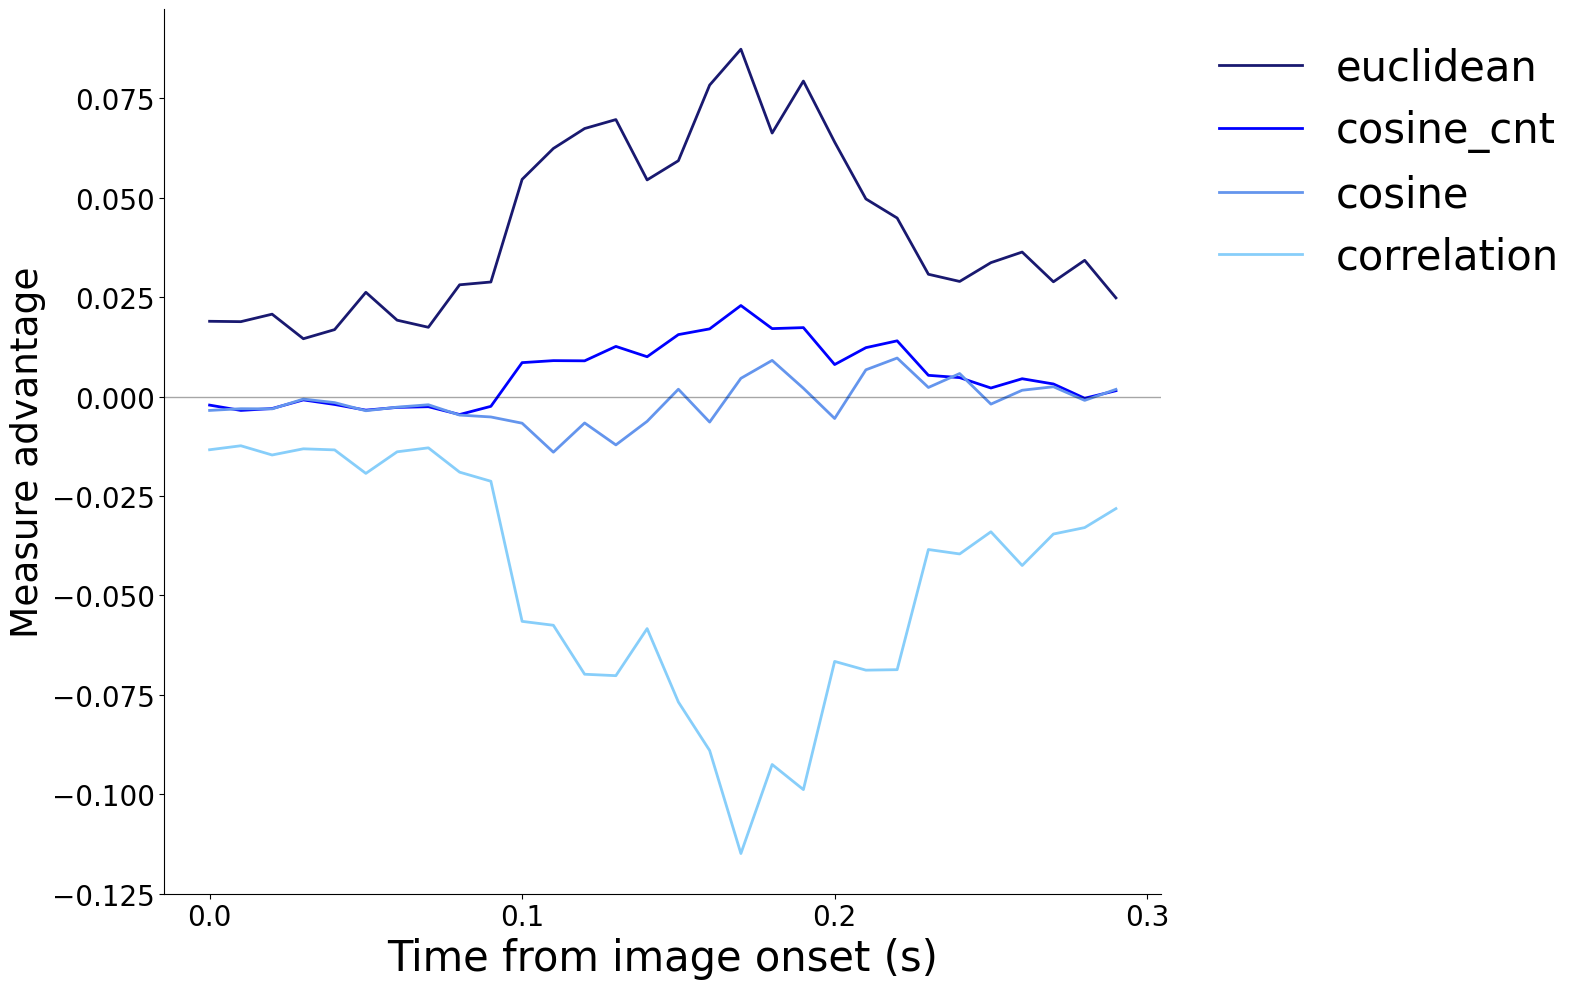

In [180]:
from dataclasses import dataclass

@dataclass
class MetricTimecourseCfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    new_fs: int = 100
    ks: tuple = (1, 10, 50, 100)
    all_metrics: tuple = ("euclidean", "cosine_cnt", "cosine",  "correlation")
    node_colors: tuple = ("midnightblue", "blue", "cornflowerblue", "lightskyblue")
    results_dir: Path = Path(paths["data_path"]) / "results"
    subsamples_size = None
    iterations = None
    k_for_monkey_timecourse: int = 1

metric_timecourse_cfg = MetricTimecourseCfg()
metric_timecourse_cfg


def metric_comparison_path(metric_from, metric_to, k, monkey_name=None, date=None, brain_area=None):
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            metric_timecourse_cfg.monkey_name if monkey_name is None else monkey_name,
            metric_timecourse_cfg.date if date is None else date,
            metric_timecourse_cfg.brain_area if brain_area is None else brain_area,
            metric_timecourse_cfg.new_fs,
            subsamples_size=metric_timecourse_cfg.subsamples_size,
            n_iterations=metric_timecourse_cfg.iterations,
        )
    )


def load_metric_comparison_timecourse(metric_from, metric_to, k):
    fn = metric_comparison_path(metric_from, metric_to, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


k = metric_timecourse_cfg.k_for_monkey_timecourse
metric_advantage = {}
missing = []

for metric_A in metric_timecourse_cfg.all_metrics:
    pairwise_differences = []
    for metric_B in metric_timecourse_cfg.all_metrics:
        if metric_A == metric_B:
            continue
        try:
            A2B = load_metric_comparison_timecourse(metric_A, metric_B, k)
            B2A = load_metric_comparison_timecourse(metric_B, metric_A, k)
        except FileNotFoundError as err:
            missing.append(str(err))
            continue
        pairwise_differences.append(A2B - B2A)

    if pairwise_differences:
        metric_advantage[metric_A] = np.nanmean(np.stack(pairwise_differences), axis=0)

if not metric_advantage:
    for fn in missing:
        print(f"missing: {fn}")
    raise FileNotFoundError("No metric-comparison pairs found for the configured metrics")

n_time = len(next(iter(metric_advantage.values())))
t = np.arange(n_time) / metric_timecourse_cfg.new_fs

fig, ax = plt.subplots(figsize=(16, 10))
colors = list(metric_timecourse_cfg.node_colors)

for color, metric in zip(colors, metric_timecourse_cfg.all_metrics):
    if metric not in metric_advantage:
        continue
    ax.plot(
        t,
        -metric_advantage[metric],
        linewidth=2,
        color=color,
        label=metric,
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.set_xlabel("Time from image onset (s)", fontsize=super_cfg.labels_fontsize)
ax.set_ylabel("Measure advantage", fontsize=super_cfg.labels_fontsize-3)
ax.tick_params(axis="both", labelsize=super_cfg.ticks_fontsize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=super_cfg.labels_fontsize,
)
plt.tight_layout()

if missing:
    print(f"Skipped {len(missing)} missing files")
    for fn in missing[:10]:
        print(f"missing: {fn}")

if super_cfg.save_figs:
    fig.savefig(f"{super_cfg.figs_folder}/metric_comparison_timecourse.pdf")


In [151]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "euclidean"
    model_RDM_metric: str = "euclidean"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    k: int = 1
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 3
    alpha: float = 0.9
    ylim: tuple[float, float] | None = (-.05, .17)
    dynii_direction: str = "A2B"
    dynii_ylim: tuple[float, float] | None = None
    dynii_subsamples_size: int | None = 200
    dynii_n_iterations: int | None = 20

cfg = Cfg()

cfg
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(f"{len(layers)} layers")

def static_drsa_save_name(layer_name):
    return cfg.results_dir / f"static_dRSA_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"

# curves = {}
# missing = []
# for layer_name in layers:
#     save_name = static_drsa_save_name(layer_name)
#     if save_name.exists():
#         curves[layer_name] = np.load(save_name)["arr_0"]
#     else:
#         missing.append(save_name)

# if not curves:
#     raise FileNotFoundError(f"No static dRSA files found in {cfg.results_dir}")

# print(f"loaded {len(curves)} / {len(layers)} layers")
# if missing:
#     print(f"missing {len(missing)} files")
#     for save_name in missing[:5]:
#         print(save_name)


# fig, ax_time = plt.subplots(figsize=(10, 6))
# cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
# norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

# for i, layer_name in enumerate(layers):
#     if layer_name not in curves:
#         continue
#     drsa = curves[layer_name]
#     t = np.arange(len(drsa)) / cfg.new_fs
#     ax_time.plot(
#         t,
#         drsa,
#         color=cmap(norm(i)),
#         linewidth=cfg.line_width,
#         alpha=cfg.alpha,
#         label=layer_name,
#     )

# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# cbar = fig.colorbar(sm, ax=ax_time, pad=0.02)
# cbar.set_ticks([0, len(layers) - 1])
# cbar.set_ticklabels(["early", "late"], fontsize=super_cfg.ticks_fontsize)
# cbar.set_label("Layer depth", fontsize=super_cfg.ticks_fontsize + 5, labelpad=1)
# cbar.ax.yaxis.set_label_coords(1.6, 0.5)

# ax_time.set_xlabel("Time from image onset (s)", fontsize=super_cfg.labels_fontsize)
# ax_time.set_ylabel("RSA similarity", fontsize=super_cfg.labels_fontsize)
# ax_time.tick_params(axis="both", labelsize=super_cfg.ticks_fontsize)
# ax_time.spines[["top", "right"]].set_visible(False)
# ax_time.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
# if cfg.ylim is not None:
#     ax_time.set_ylim(*cfg.ylim)
# ax_time.set_title("aa", fontsize=super_cfg.title_fontsize)
# if len(curves) <= 12:
#     ax_time.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

# plt.tight_layout()
# plt.show()


24 layers


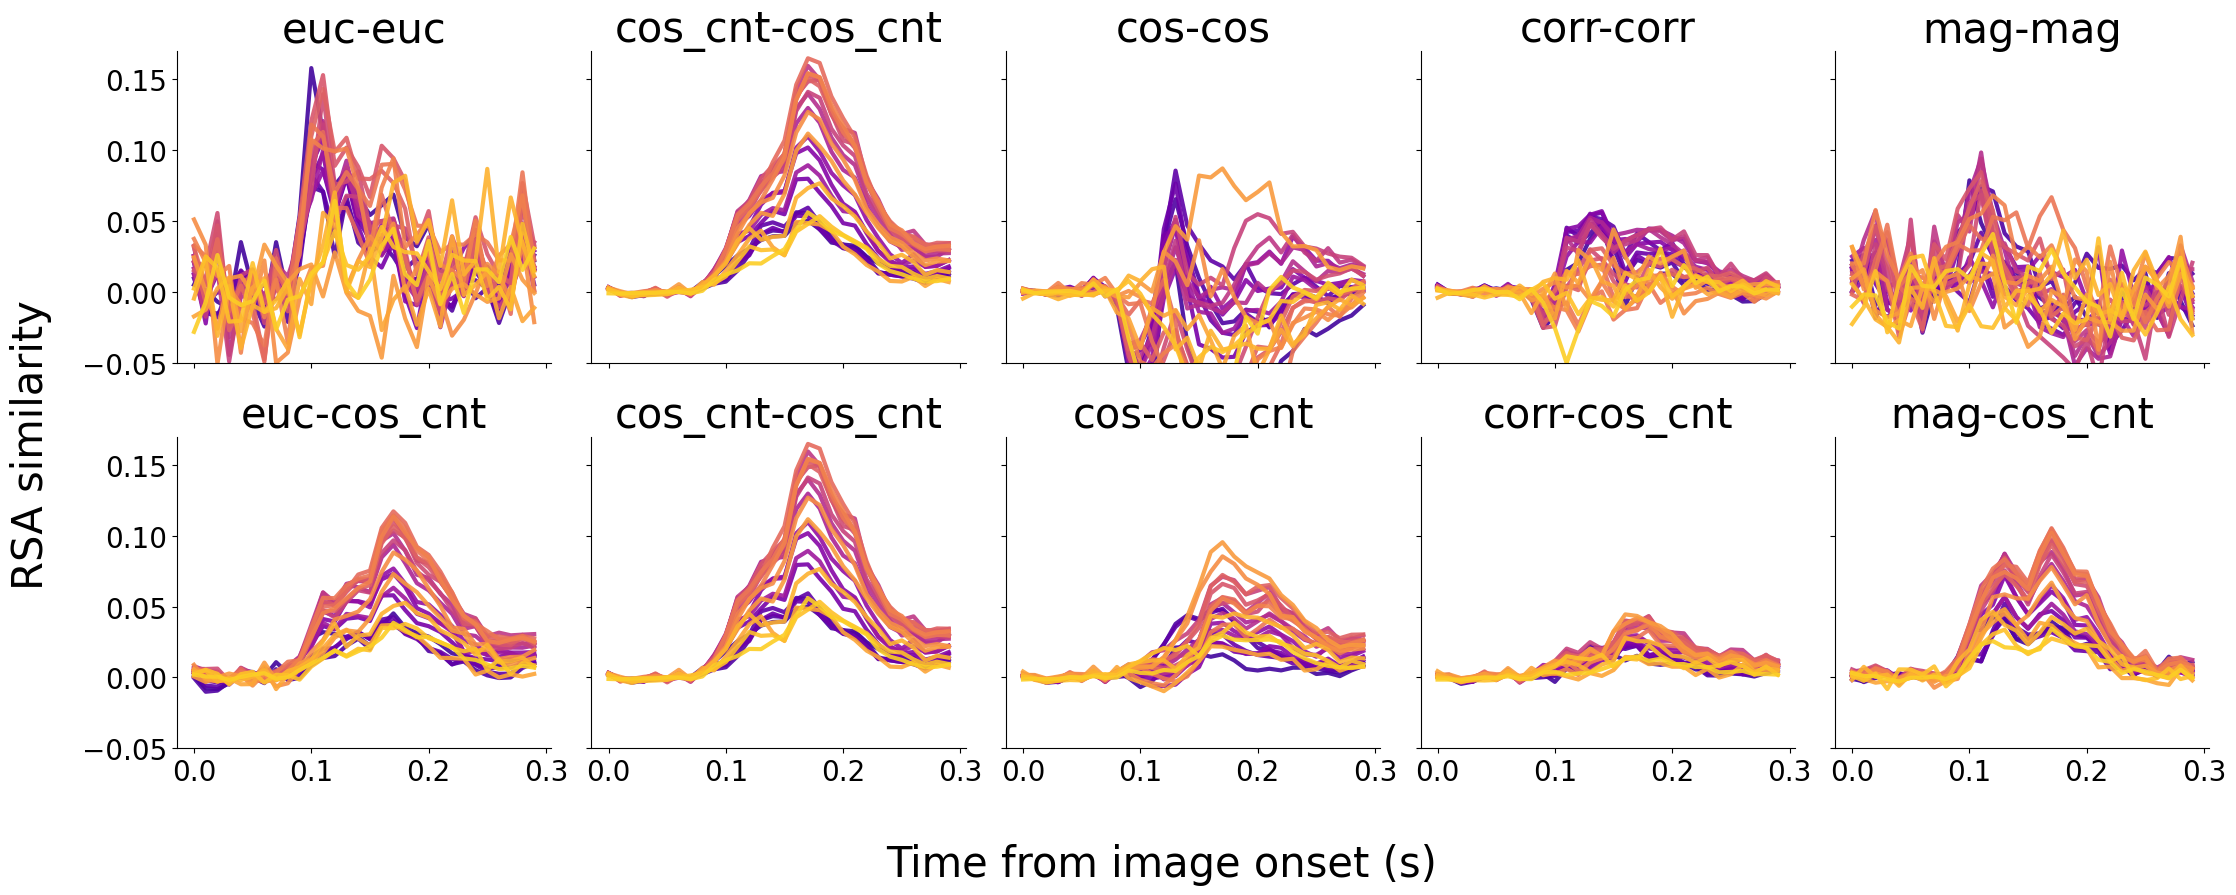

In [152]:
drsa_metrics = ["euclidean", "cosine_cnt", "cosine", "correlation", "magnitude_diff"]
metric_labels = {
    "euclidean": "euc",
    "cosine": "cos",
    "cosine_cnt": "cos_cnt",
    "correlation": "corr",
    "magnitude_diff": "mag",
}

metric_grid = [
    [(metric, metric) for metric in drsa_metrics],
    [(metric, "cosine_cnt") for metric in drsa_metrics],
]


def static_drsa_metric_save_name(signal_metric, model_metric, layer_name):
    return cfg.results_dir / f"static_dRSA_{signal_metric}-{model_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"


fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharex=True, sharey=True)
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for row_idx, row in enumerate(metric_grid):
    for col_idx, (signal_metric, model_metric) in enumerate(row):
        ax = axes[row_idx, col_idx]
        loaded = 0
        for layer_idx, layer_name in enumerate(layers):
            save_name = static_drsa_metric_save_name(signal_metric, model_metric, layer_name)
            if not save_name.exists():
                continue
            drsa = np.load(save_name)["arr_0"]
            t = np.arange(len(drsa)) / cfg.new_fs
            ax.plot(
                t,
                drsa,
                color=cmap(norm(layer_idx)),
                linewidth=cfg.line_width,
                alpha=cfg.alpha,
            )
            loaded += 1

        title = f"{metric_labels[signal_metric]}-{metric_labels[model_metric]}"
        ax.set_title(title, fontsize=super_cfg.labels_fontsize)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="both", labelsize=super_cfg.ticks_fontsize)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
        if cfg.ylim is not None:
            ax.set_ylim(*cfg.ylim)
        if loaded == 0:
            ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", fontsize=super_cfg.ticks_fontsize)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# cbar = fig.colorbar(sm, ax=axes, pad=0.01, shrink=0.9)
# cbar.set_ticks([0, len(layers) - 1])
# cbar.set_ticklabels(["early", "late"], fontsize=super_cfg.ticks_fontsize)
# cbar.set_label("Layer depth", fontsize=super_cfg.ticks_fontsize + 5, labelpad=1)
fig.supxlabel("Time from image onset (s)", fontsize=super_cfg.labels_fontsize)
fig.supylabel("RSA similarity", fontsize=super_cfg.labels_fontsize)
plt.tight_layout(rect=(0.02, 0.04, 0.95, 1))
plt.show()
if super_cfg.save_figs:
    fig.savefig(f"{super_cfg.figs_folder}/all_dRSA_combinations.pdf")


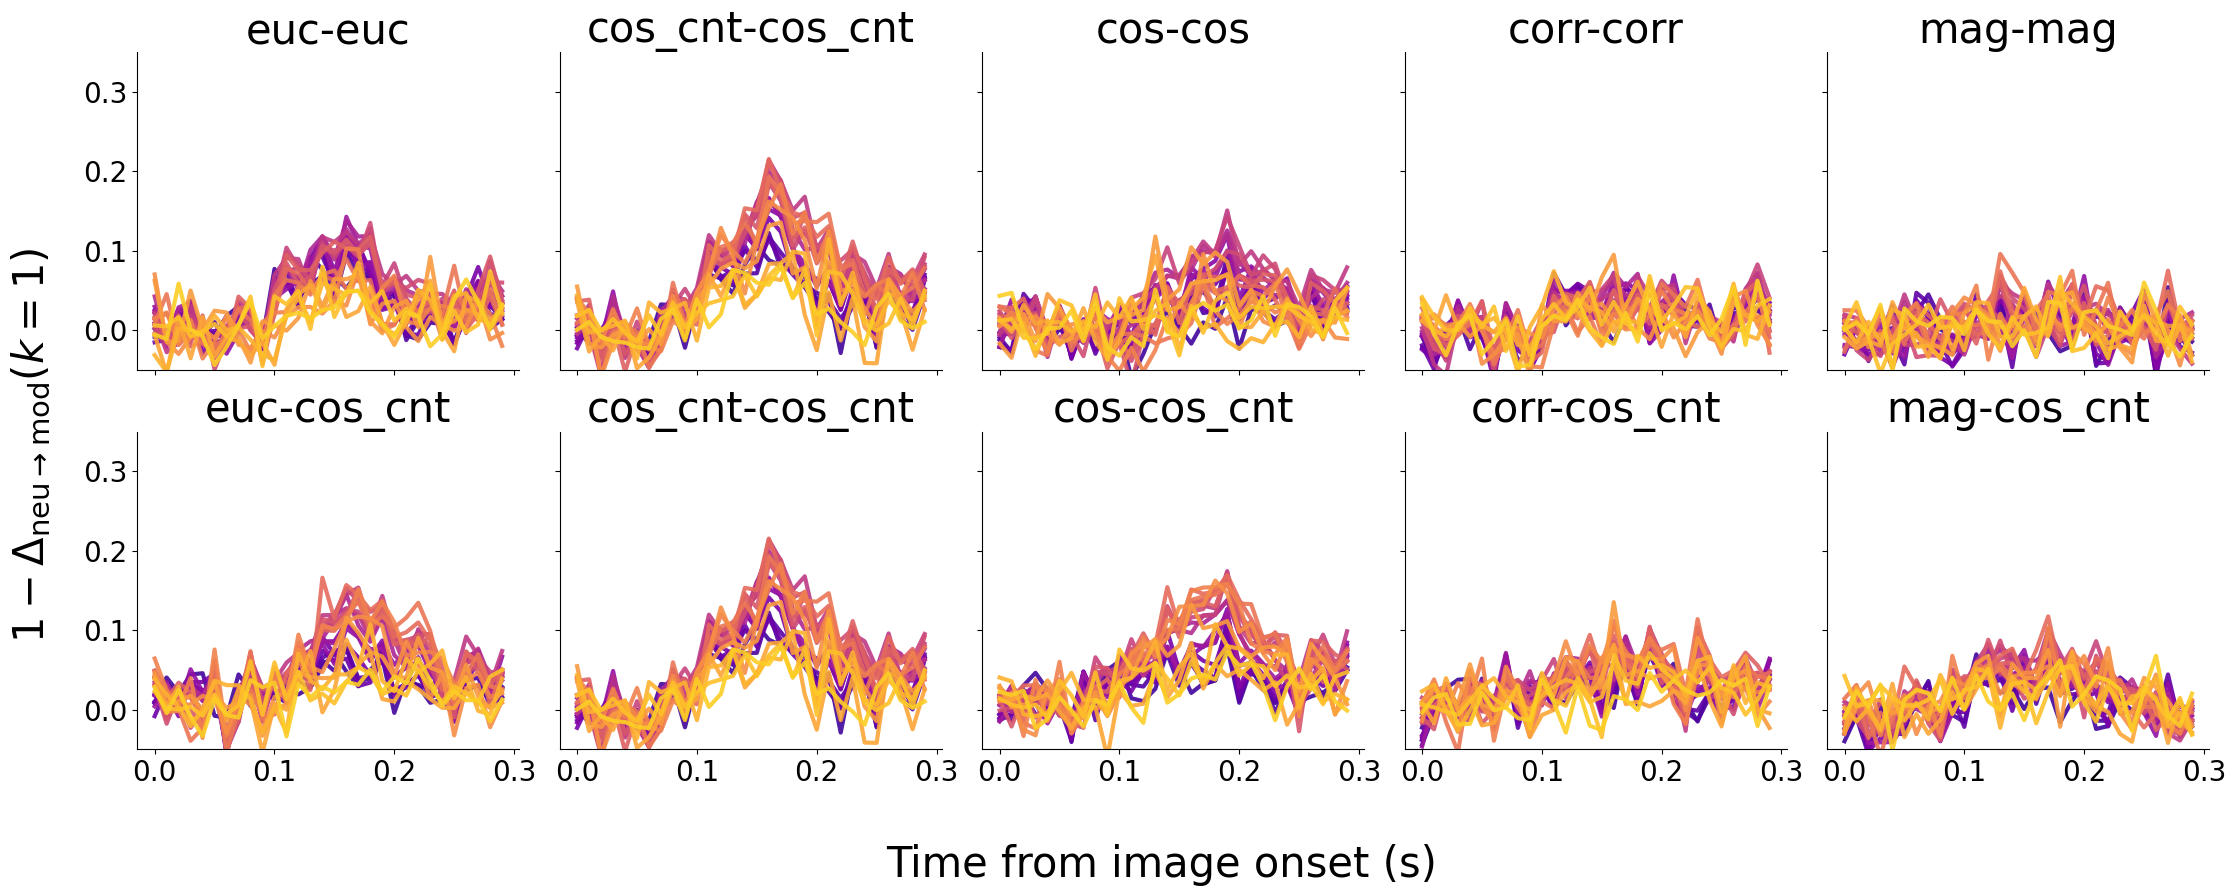

In [148]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "euclidean"
    model_RDM_metric: str = "euclidean"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    k: int = 1
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 3
    alpha: float = 0.9

    dynii_direction: str = "A2B"
    dynii_ylim: tuple[float, float] | None = (-.05, .35)


cfg = Cfg()

dynii_metrics = ["euclidean", "cosine_cnt", "cosine", "correlation", "magnitude_diff"]
metric_labels = {
    "euclidean": "euc",
    "cosine": "cos",
    "cosine_cnt": "cos_cnt",
    "correlation": "corr",
    "magnitude_diff": "mag",
}

dynii_metric_grid = [
    [(metric, metric) for metric in dynii_metrics],
    [(metric, "cosine_cnt") for metric in dynii_metrics],
]


def static_dynii_metric_save_name(signal_metric, model_metric, layer_name, direction=None):
    direction = cfg.dynii_direction if direction is None else direction
    return cfg.results_dir / f"dynII_{direction}_k{cfg.k}_{signal_metric}-{model_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"


fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharex=True, sharey=True)
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for row_idx, row in enumerate(dynii_metric_grid):
    for col_idx, (signal_metric, model_metric) in enumerate(row):
        ax = axes[row_idx, col_idx]
        loaded = 0
        for layer_idx, layer_name in enumerate(layers):
            save_name = static_dynii_metric_save_name(signal_metric, model_metric, layer_name, direction=cfg.dynii_direction)
            if not save_name.exists():
                continue
            dynii = 1- np.load(save_name)["arr_0"]
            t = np.arange(len(dynii)) / cfg.new_fs
            ax.plot(
                t,
                dynii,
                color=cmap(norm(layer_idx)),
                linewidth=cfg.line_width,
                alpha=cfg.alpha,
            )
            loaded += 1

        title = f"{metric_labels[signal_metric]}-{metric_labels[model_metric]}"
        ax.set_title(title, fontsize=super_cfg.labels_fontsize)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="both", labelsize=super_cfg.ticks_fontsize)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
        if loaded == 0:
            ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", fontsize=super_cfg.ticks_fontsize)

if cfg.dynii_ylim is not None:
    for ax in axes.flat:
        ax.set_ylim(*cfg.dynii_ylim)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

fig.supxlabel("Time from image onset (s)", fontsize=super_cfg.labels_fontsize)
label_direction = (
    r"\mathrm{mod}\to\mathrm{neu}"
    if cfg.dynii_direction == "B2A"
    else r"\mathrm{neu}\to\mathrm{mod}"
)

fig.supylabel(
    rf"$1 - \Delta_{{{label_direction}}}(k={cfg.k})$",
    fontsize=super_cfg.labels_fontsize,
)

plt.tight_layout(rect=(0.02, 0.04, 0.95, 1))
plt.show()
if super_cfg.save_figs:
    fig.savefig(f"{super_cfg.figs_folder}/all_dynII_{cfg.dynii_direction}_k{cfg.k}_combinations.pdf")


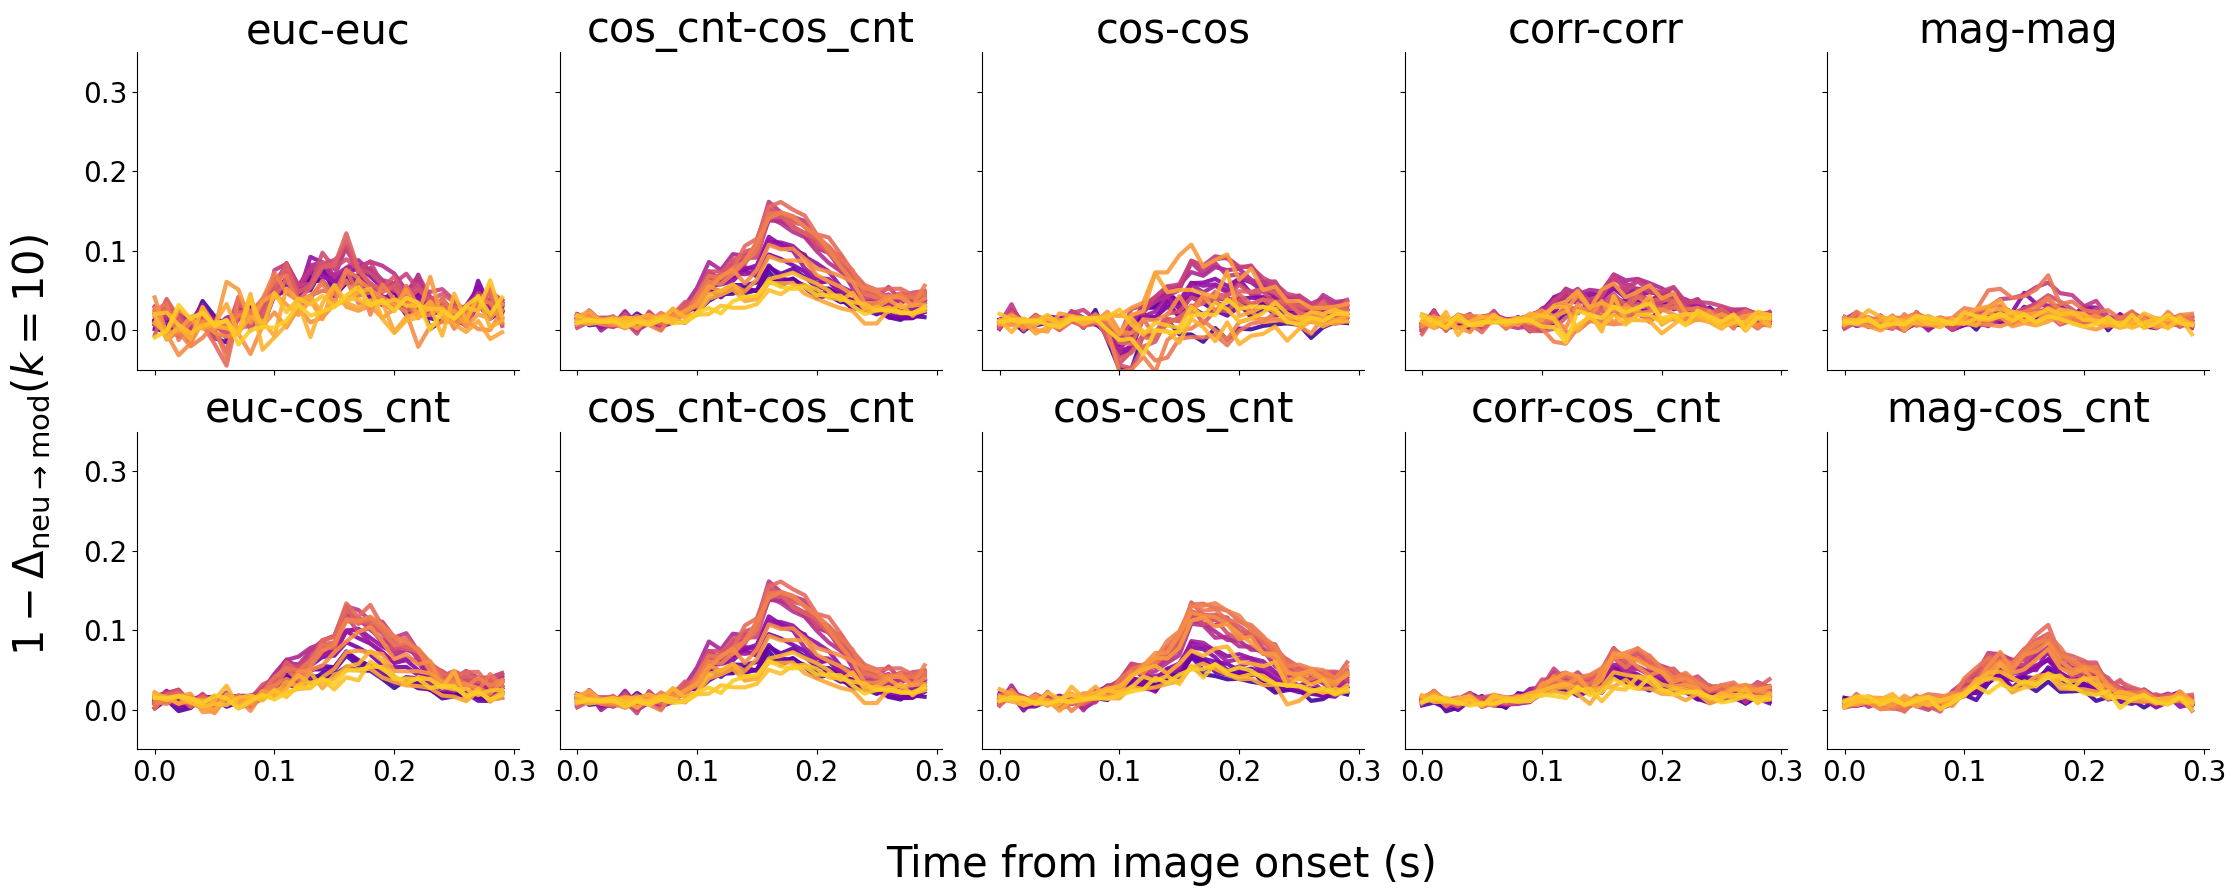

In [146]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "euclidean"
    model_RDM_metric: str = "euclidean"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    k: int = 10
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 3
    alpha: float = 0.9
    dynii_direction: str = "A2B"
    dynii_ylim: tuple[float, float] | None = (-.05, .35)
    dynii_subsamples_size: int | None = 200
    dynii_n_iterations: int | None = 20

cfg = Cfg()

subsampled_dynii_metrics = ["euclidean", "cosine_cnt", "cosine", "correlation", "magnitude_diff"]
metric_labels = {
    "euclidean": "euc",
    "cosine": "cos",
    "cosine_cnt": "cos_cnt",
    "correlation": "corr",
    "magnitude_diff": "mag",
}

subsampled_dynii_metric_grid = [
    [(metric, metric) for metric in subsampled_dynii_metrics],
    [(metric, "cosine_cnt") for metric in subsampled_dynii_metrics],
]


def static_dynii_subsampled_metric_save_name(signal_metric, model_metric, layer_name, direction=None):
    direction = cfg.dynii_direction if direction is None else direction
    save_name = cfg.results_dir / f"dynII_{direction}_k{cfg.k}_{signal_metric}-{model_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz"
    save_name = Path(f"{save_name}_{cfg.dynii_subsamples_size}subsamples_{cfg.dynii_n_iterations}iterations.npz")
    return save_name


fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharex=True, sharey=True)
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for row_idx, row in enumerate(subsampled_dynii_metric_grid):
    for col_idx, (signal_metric, model_metric) in enumerate(row):
        ax = axes[row_idx, col_idx]
        loaded = 0
        for layer_idx, layer_name in enumerate(layers):
            save_name = static_dynii_subsampled_metric_save_name(signal_metric, model_metric, layer_name, direction=cfg.dynii_direction)
            if not save_name.exists():
                continue
            dynii = 1- np.load(save_name)["arr_0"]
            t = np.arange(len(dynii)) / cfg.new_fs
            ax.plot(
                t,
                dynii,
                color=cmap(norm(layer_idx)),
                linewidth=cfg.line_width,
                alpha=cfg.alpha,
            )
            loaded += 1

        title = f"{metric_labels[signal_metric]}-{metric_labels[model_metric]}"
        ax.set_title(title, fontsize=super_cfg.labels_fontsize)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="both", labelsize=super_cfg.ticks_fontsize)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
        if loaded == 0:
            ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", fontsize=super_cfg.ticks_fontsize)

if cfg.dynii_ylim is not None:
    for ax in axes.flat:
        ax.set_ylim(*cfg.dynii_ylim)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.supxlabel("Time from image onset (s)", fontsize=super_cfg.labels_fontsize)
label_direction = (
    r"\mathrm{mod}\to\mathrm{neu}"
    if cfg.dynii_direction == "B2A"
    else r"\mathrm{neu}\to\mathrm{mod}"
)

fig.supylabel(
    rf"$1 - \Delta_{{{label_direction}}}(k={cfg.k})$",
    fontsize=super_cfg.labels_fontsize,
)

plt.tight_layout(rect=(0.02, 0.04, 0.95, 1))
plt.show()
if super_cfg.save_figs:
    fig.savefig(
        f"{super_cfg.figs_folder}/all_dynII_{cfg.dynii_direction}_k{cfg.k}_combinations_{cfg.dynii_subsamples_size}subsamples_{cfg.dynii_n_iterations}iterations.pdf"
    )


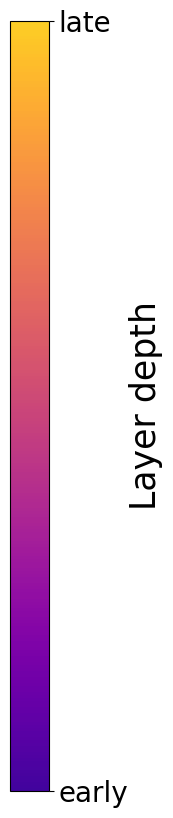

In [137]:
fig, ax = plt.subplots(figsize=(.5, 10))
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax)
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"], fontsize=super_cfg.ticks_fontsize)
cbar.set_label("Layer depth", fontsize=super_cfg.ticks_fontsize + 5, labelpad=1)

if super_cfg.save_figs:
    figs_folder = Path(super_cfg.figs_folder)
    figs_folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(figs_folder / "layer_depth_colorbar.pdf", bbox_inches="tight")
    

plt.show()
